# SOB4ES - Modelo de Regresion (Ridge)
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook recorre el ciclo de vida completo del modelo de regresion lineal regularizada (Ridge Regression).

Se usa Ridge en lugar de regresion lineal simple porque regulariza los coeficientes (penalizacion L2), lo que mejora la estabilidad cuando hay variables correlacionadas o cuando el numero de predictores es alto.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por pais)
- `test.csv`  - Busqueda de hiperparametros y validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final e imparcial del rendimiento (15 %)

**Estructura del notebook:**
1. Configuracion: importaciones y parametros globales.
2. Carga de datos: se cargan los tres splits pre-generados.
3. Tuning: busqueda del valor optimo de regularizacion alpha.
4. Validacion cruzada: evaluacion de robustez.
5. Importancia de variables: coeficientes y permutation importance.
6. Produccion: entrenamiento final y exportacion de modelos.
7. Evaluacion final: rendimiento real sobre `eval.csv`.

---
## 1.- Configuracion del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ignoramos los warnings
warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/reg/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

Librerias y variables cargadas correctamente...


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la division 70/15/15 estratificada por pais.

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimacion imparcial del rendimiento.

In [2]:
def cargar_csv(ruta, nombre):
    """Carga un CSV (sep=',' o ';') y valida las columnas necesarias."""
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontro el archivo: {ruta}")
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f"  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)


## 3.- Busqueda de hiperparametros (Tuning)

En Ridge Regression el principal hiperparametro es `alpha`, que controla la intensidad de la regularizacion:
- `alpha` cercano a 0: comportamiento similar a la regresion lineal ordinaria (sin regularizacion).
- `alpha` alto: coeficientes mas penalizados, modelo mas simple y resistente al sobreajuste.

Tambien se exploran `fit_intercept` y el `solver` numerico. La busqueda se realiza exclusivamente sobre `X_train`.

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar varios minutos...

Buscando hiperparametros para: earthworm_shannon_z
Fitting 5 folds for each of 150 candidates, totalling 750 fits
  R2: 0.2868  |  tiempo: 0.0 min
  Params: {'tol': 0.001, 'solver': 'auto', 'random_state': 42, 'positive': False, 'max_iter': 1000, 'fit_intercept': False, 'copy_X': True, 'alpha': np.float64(28.064708463098388)}

Buscando hiperparametros para: earthworm_richness_z
Fitting 5 folds for each of 150 candidates, totalling 750 fits
  R2: 0.3745  |  tiempo: 0.0 min
  Params: {'tol': 0.001, 'solver': 'auto', 'random_state': 42, 'positive': False, 'max_iter': 1000, 'fit_intercept': False, 'copy_X': True, 'alpha': np.float64(28.064708463098388)}

Calculando consenso de hiperparametros...
  Peso earthworm_shannon_z  : 0.434
  Peso earthworm_richness_z : 0.566

Hiperparametros consenso finales:
  alpha: 28.06470846309839
  fit_intercept: False
  solver: auto
  copy_X: True


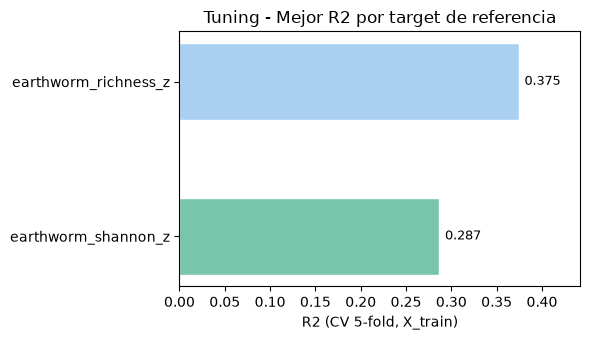

In [3]:
print('Iniciando busqueda de hiperparametros (Tuning)...')
print('Este proceso puede tardar varios minutos...\n')

# Ridge Regression: el unico hiperparametro clave es alpha (regularizacion L2)
param_grid = {
    'alpha': np.logspace(-4, 5, 300),
    'fit_intercept': [True, False],
    'copy_X': [True],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga', 'sparse_cg'],
    'tol': [1e-4, 1e-3, 1e-2],
    'max_iter': [None, 500, 1000, 3000],
    'random_state': [42],
    'positive': [False],
}

# Buscamos los hiperparametros optimos para los targets de referencia
referencias = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

resultados_tuning = {}

for nombre_target, y_prueba in referencias.items():
    print(f'Buscando hiperparametros para: {nombre_target}')
    buscador = RandomizedSearchCV(
        estimator=Ridge(),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    start = time.time()
    buscador.fit(X_train, y_prueba)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f'  R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min')
    print(f'  Params: {buscador.best_params_}\n')

# Consenso de hiperparametros 
# Para parametros numericos (alpha, tol, max_iter) se toma la media ponderada
# por R2 de cada target, de forma que el target con mejor ajuste tiene mas peso.
# Para parametros categoricos (solver, fit_intercept) se toma el valor del
# target con mayor R2, ya que no tiene sentido promediar categorias.

params_s = resultados_tuning['earthworm_shannon_z']['params']
params_r = resultados_tuning['earthworm_richness_z']['params']
r2_s     = resultados_tuning['earthworm_shannon_z']['r2']
r2_r     = resultados_tuning['earthworm_richness_z']['r2']

# Pesos proporcionales al R2 de cada target
w_s = r2_s / (r2_s + r2_r)
w_r = r2_r / (r2_s + r2_r)

print('Calculando consenso de hiperparametros...')
print(f'  Peso earthworm_shannon_z  : {w_s:.3f}')
print(f'  Peso earthworm_richness_z : {w_r:.3f}')

# Alpha: media geometrica ponderada
alpha_consenso = np.exp(w_s * np.log(params_s['alpha']) +
                        w_r * np.log(params_r['alpha']))

# fit_intercept: valor del target con mayor R2
fit_intercept_consenso = params_s['fit_intercept'] if r2_s >= r2_r else params_r['fit_intercept']

# solver: valor del target con mayor R2
solver_consenso = params_s['solver'] if r2_s >= r2_r else params_r['solver']

# tol: media ponderada si ambos la tienen, si no el que la tenga
tol_s = params_s.get('tol', 1e-3)
tol_r = params_r.get('tol', 1e-3)
tol_consenso = w_s * tol_s + w_r * tol_r

# max_iter: media ponderada redondeada, si no aplica se usa 1000
max_iter_s = params_s.get('max_iter', 1000) or 1000
max_iter_r = params_r.get('max_iter', 1000) or 1000
max_iter_consenso = int(round(w_s * max_iter_s + w_r * max_iter_r))

# Construimos el dict de parametros consenso
REG_OPTIMAL_PARAMS = {
    'alpha':         alpha_consenso,
    'fit_intercept': fit_intercept_consenso,
    'solver':        solver_consenso,
    'copy_X':        True,
}

# Anadir tol y max_iter solo si el solver consenso los necesita
if solver_consenso in ('lsqr', 'sparse_cg', 'sag', 'saga'):
    REG_OPTIMAL_PARAMS['tol']      = tol_consenso
    REG_OPTIMAL_PARAMS['max_iter'] = max_iter_consenso

if solver_consenso in ('sag', 'saga'):
    REG_OPTIMAL_PARAMS['random_state'] = 42

print('\nHiperparametros consenso finales:')
for k, v in REG_OPTIMAL_PARAMS.items():
    print(f'  {k}: {v}')

# Grafico: R2 de tuning por target de referencia
_tuning_r2 = {
    'earthworm_shannon_z':  resultados_tuning['earthworm_shannon_z']['r2'],
    'earthworm_richness_z': resultados_tuning['earthworm_richness_z']['r2'],
}
fig, ax = plt.subplots(figsize=(6, 3.5))
_bars = ax.barh(
    list(_tuning_r2.keys()),
    list(_tuning_r2.values()),
    color=["#77C5AA", "#AAD0F1"],
    edgecolor='white', height=0.5
)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=9)
ax.set_xlim(0, max(_tuning_r2.values()) * 1.18)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target de referencia', fontsize=12)
ax.axvline(0, color='#AAAAAA', linewidth=0.8)
plt.tight_layout()
plt.show()


## 4.- Validacion cruzada

Se evalua la robustez del modelo con validacion cruzada repetida (5 pliegues x 3 repeticiones = 15 evaluaciones) sobre `X_train`. En regresion lineal la diferencia entre train y validacion suele ser pequena; una diferencia grande indicaria que el modelo no captura bien la relacion entre variables.

In [4]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

referencias_cv = {
    'earthworm_shannon_z':  y_train['earthworm_shannon_z'].values,
    'earthworm_richness_z': y_train['earthworm_richness_z'].values,
}

for nombre_target, y_prueba in referencias_cv.items():
    print(f'Target: {nombre_target}')
    print('-' * 55)

    modelo_cv  = Ridge(**REG_OPTIMAL_PARAMS)
    resultados = cross_validate(
        estimator=modelo_cv,
        X=X_train,
        y=y_prueba,
        cv=cv_splitter,
        scoring=metricas,
        return_train_score=True
    )

    r2_train = np.mean(resultados['train_r2'])
    r2_cv    = np.mean(resultados['test_r2'])
    r2_std   = np.std(resultados['test_r2'])
    rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
    mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

    print(f'  Train R2          : {r2_train:.4f}')
    print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
    print(f'  RMSE              : {rmse_cv:.4f} {nombre_target}')
    print(f'  MAE               : {mae_cv:.4f} {nombre_target}')

    diferencia = r2_train - r2_cv
    if diferencia > 0.15:
        print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.')
    else:
        print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.')
    print()

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

Target: earthworm_shannon_z
-------------------------------------------------------
  Train R2          : 0.4581
  Validacion R2 (CV): 0.2954 +/- 0.0640
  RMSE              : 0.8144 earthworm_shannon_z
  MAE               : 0.6433 earthworm_shannon_z
  Aviso: diferencia train/val = 0.1627. Posible sobreajuste.

Target: earthworm_richness_z
-------------------------------------------------------
  Train R2          : 0.5134
  Validacion R2 (CV): 0.4048 +/- 0.0715
  RMSE              : 0.7515 earthworm_richness_z
  MAE               : 0.5849 earthworm_richness_z
  Diferencia train/val = 0.1087. El modelo generaliza correctamente.



## 5.- Importancia de variables

La regresion lineal no es compatible con `TreeExplainer` de SHAP. Se utilizan dos enfoques complementarios:
- **Permutation importance:** mide cuanto cae el R2 cuando se baraja aleatoriamente cada variable. Es independiente del tipo de modelo.
- **Coeficientes del modelo:** directamente interpretables en Ridge, ya que las variables estan normalizadas (escala z).

Calculando importancia de variables mediante permutacion sobre X_train...
Se usan dos targets de referencia: earthworm_shannon_z y earthworm_richness_z

Top 10 variables por importancia de permutacion (promedio shannon + richness):
soil_ph_z                 0.4496
eu_p_z                    0.3417
silt_content_z            0.0979
plot_total_organic_c_z    0.0593
clay_content_z            0.0558
gee_humedad_rel_pct_z     0.0504
eu_clay_content_z         0.0335
plot_total_n_z            0.0326
eu_cn_ratio_z             0.0297
aggregate_stability_z     0.0285

Top 10 coeficientes por valor absoluto (earthworm_shannon_z):
soil_ph_z                 0.474406
eu_p_z                    0.345205
silt_content_z            0.213087
plot_total_organic_c_z    0.145367
clay_content_z            0.144320
gee_humedad_rel_pct_z     0.141647
eu_cn_ratio_z             0.137548
eu_clay_content_z         0.128570
plot_total_n_z            0.117124
aggregate_stability_z     0.115624


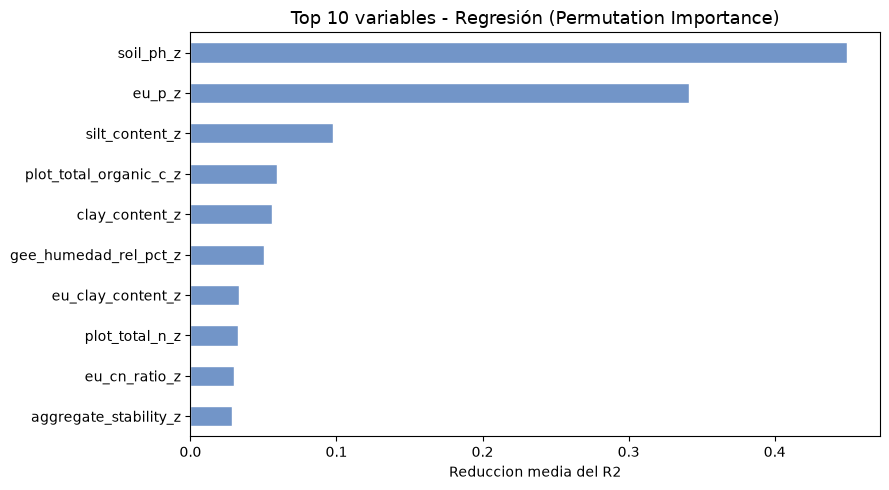

In [5]:
print('Calculando importancia de variables mediante permutacion sobre X_train...')
print('Se usan dos targets de referencia: earthworm_shannon_z y earthworm_richness_z')

# Permutation importance promediado sobre shannon y richness de referencia
modelo_imp_s = Ridge(**REG_OPTIMAL_PARAMS)
modelo_imp_s.fit(X_train, y_train['earthworm_shannon_z'].values)

modelo_imp_r = Ridge(**REG_OPTIMAL_PARAMS)
modelo_imp_r.fit(X_train, y_train['earthworm_richness_z'].values)

result_s = permutation_importance(modelo_imp_s, X_train, y_train['earthworm_shannon_z'].values,
    n_repeats=10, random_state=42, n_jobs=-1)
result_r = permutation_importance(modelo_imp_r, X_train, y_train['earthworm_richness_z'].values,
    n_repeats=10, random_state=42, n_jobs=-1)

# Promediamos la importancia de ambos targets
imp_mean = (result_s.importances_mean + result_r.importances_mean) / 2
importancias = pd.Series(imp_mean, index=FEATURES_AUTORIZADAS)
top10 = importancias.nlargest(10)

print('\nTop 10 variables por importancia de permutacion (promedio shannon + richness):')
print(top10.round(4).to_string())

# Coeficientes directos del modelo Shannon (como referencia)
print('\nTop 10 coeficientes por valor absoluto (earthworm_shannon_z):')
coefs = pd.Series(modelo_imp_s.coef_, index=FEATURES_AUTORIZADAS)
print(coefs.abs().nlargest(10).to_string())

# Grafico: barplot importancia de variables

fig, ax = plt.subplots(figsize=(9, 5))
top10.sort_values().plot(kind='barh', ax=ax, color="#7295C8", edgecolor='white')
ax.set_title('Top 10 variables - Regresión (Permutation Importance)', fontsize=13)
ax.set_xlabel('Reduccion media del R2')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6.- Entrenamiento de produccion

La regresion lineal es determinista (no depende de semillas aleatorias), por lo que se entrena un unico modelo por variable objetivo. Cada modelo se guarda en disco en formato `.pkl`.

In [6]:
print('Entrenamiento de produccion (un modelo por target, sin ensamble)...')

global_start = time.time()

for idx, target_col in enumerate(TARGETS, 1):
    t0 = time.time()
    y  = y_train[target_col].values

    model = Ridge(**REG_OPTIMAL_PARAMS)
    model.fit(X_train, y)

    ruta = os.path.join(MODELS_DIR, f'ridge_prod_{target_col}.pkl')
    joblib.dump(model, ruta)

    print(f'  [{idx}/{len(TARGETS)}] {target_col:30} completado ({time.time()-t0:.2f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time() - global_start):.1f} segundos.')
print(f'Modelos guardados: {len(TARGETS)}')


Entrenamiento de produccion (un modelo por target, sin ensamble)...
  [1/21] nematode_shannon_z             completado (0.00s)
  [2/21] macro_shannon_z                completado (0.00s)
  [3/21] earthworm_shannon_z            completado (0.00s)
  [4/21] orib_shannon_z                 completado (0.00s)
  [5/21] meso_shannon_z                 completado (0.00s)
  [6/21] coll_shannon_z                 completado (0.00s)
  [7/21] bac_shannon_z                  completado (0.00s)
  [8/21] fun_shannon_z                  completado (0.00s)
  [9/21] euk_shannon_z                  completado (0.00s)
  [10/21] oomy_shannon_z                 completado (0.00s)
  [11/21] cerc_shannon_z                 completado (0.00s)
  [12/21] macro_order_richness_z         completado (0.00s)
  [13/21] earthworm_richness_z           completado (0.00s)
  [14/21] orib_species_richness_z        completado (0.00s)
  [15/21] meso_species_richness_z        completado (0.00s)
  [16/21] coll_species_richness_z        

## 7.- Evaluacion final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimacion real del rendimiento en produccion. A continuacion se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Interpretacion del indice Shannon H':** 
El modelo predice el indice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  nematode_shannon_z              -0.0703   1.0217   0.8105
  macro_shannon_z                  0.0514   0.9783   0.8347
  earthworm_shannon_z              0.2991   0.8357   0.6324
  orib_shannon_z                   0.1475   1.0558   0.8789
  meso_shannon_z                  -0.4939   1.1936   0.9383
  coll_shannon_z                  -1.0871   0.9152   0.6934
  bac_shannon_z                   -0.1034   1.0519   0.7278
  fun_shannon_z                   -0.2000   1.2533   1.0476
  euk_shannon_z                    0.0134   0.9633   0.7092
  oomy_shannon_z                  -0.0130   1.0521   0.7784
  cerc_shannon_z                  -0.0106   0.9002   0.6808
  macro_order_richness_z           0.1007   0.8685   0.7171
  earthworm_richness_z             0.2698   0.7803   0.5

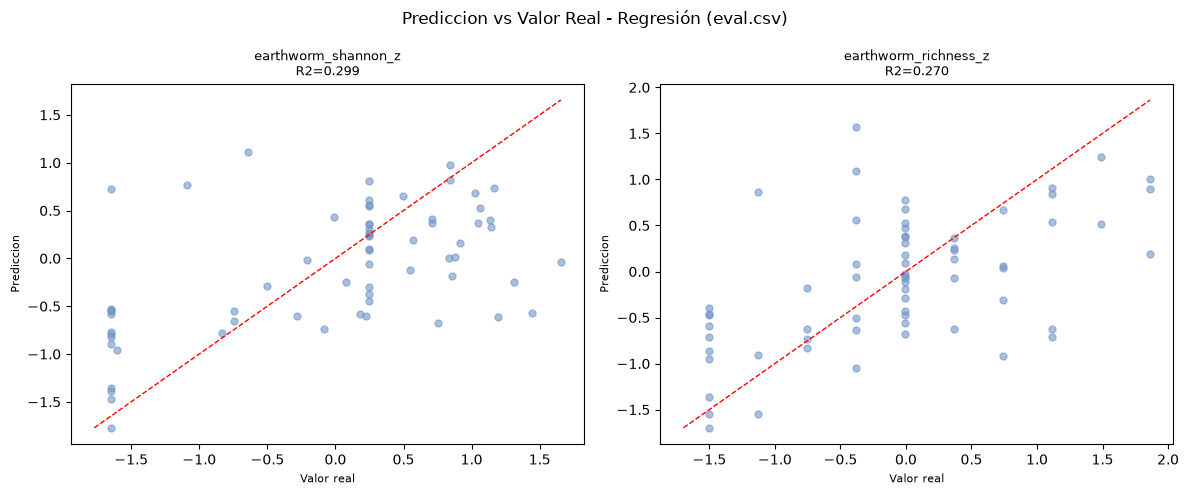

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Evaluacion final sobre todos los targets

print('Evaluacion final sobre eval.csv')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

for test_target in TARGETS:
    ruta        = os.path.join(MODELS_DIR, f'ridge_prod_{test_target}.pkl')
    modelo_eval = joblib.load(ruta)
    y_pred_eval = modelo_eval.predict(X_eval)
    y_true_eval = y_eval[test_target].values

    r2   = r2_score(y_true_eval, y_pred_eval)
    rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
    mae  = mean_absolute_error(y_true_eval, y_pred_eval)
    print(f'  {test_target:30} {r2:8.4f} {rmse:8.4f} {mae:8.4f}')

print('-' * 65)


# Smoke test con datos reales
# Se prueban dos targets representativos: uno shannon y uno richness

print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    for test_target in ['earthworm_shannon_z', 'earthworm_richness_z']:
        print(f'\n  Target: {test_target}')
        print('  ' + '-' * 63)
        valores_reales = y_eval.loc[indices_elegidos, test_target].values

        ruta        = os.path.join(MODELS_DIR, f'ridge_prod_{test_target}.pkl')
        modelo_eval = joblib.load(ruta)
        pred        = modelo_eval.predict(df_new_data)
        for i, idx in enumerate(indices_elegidos):
            real_val = valores_reales[i]
            print(f'    Fila {idx:<4} | Prediccion: {pred[i]:.4f} | '
                  f'Valor Real: {real_val:.4f} | Error: {abs(pred[i]-real_val):.4f}')

    print('\nSmoke test superado. El pipeline funciona correctamente...')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['earthworm_shannon_z', 'earthworm_richness_z']):
    m  = joblib.load(os.path.join(MODELS_DIR, f'ridge_prod_{tgt}.pkl'))
    yp = m.predict(X_eval)
    yt = y_eval[tgt].values
    ax.scatter(yt, yp, alpha=0.6, s=25, color='#7295C8')
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - Regresión (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()